In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, accuracy_score

column_names = []

with open("communities.names") as f:
    for line in f:
        if line.startswith("@attribute"):
            column_names.append(line.split(" ")[1])

# Load data with proper headers
df = pd.read_csv("communities.data",
                 names=column_names,
                 na_values="?")

df = df.apply(pd.to_numeric, errors="ignore")



# Optional: drop non-predictive columns
df = df.drop(columns=["state", "county", "community", "communityname", "fold"], errors="ignore")

vars_of_interest = [
    "racepctblack",
    "racePctWhite",
    "racePctAsian",
    "racePctHisp",
    "agePct12t21",
    "agePct12t29",
    "agePct16t24",
    "agePct65up",
    "PctUsePubTrans",
    "ViolentCrimesPerPop"
]

economic_vars = [
'PctPopUnderPov',
'perCapInc',
'medIncome',
'PctUnemployed',
'PctNotHSGrad',
'PctBSorMore',
'PctWPubAsst',
'pctWInvInc',
'MedRentPctHousInc',
'PctOccupMgmtProf'
]

subset = df[vars_of_interest]

summary_table = pd.DataFrame({
    "Mean": subset.mean(),
    "Median": subset.median(),
    "Std Dev": subset.std(),
    "Min": subset.min(),
    "Max": subset.max()
})

summary_table = summary_table.round(2)

summary_table

,Mean,Median,Std Dev,Min,Max
racepctblack,0.18,0.06,0.25,0.0,1.0
racePctWhite,0.75,0.85,0.24,0.0,1.0
racePctAsian,0.15,0.07,0.21,0.0,1.0
racePctHisp,0.14,0.04,0.23,0.0,1.0
agePct12t21,0.42,0.40,0.16,0.0,1.0
agePct12t29,0.49,0.48,0.14,0.0,1.0
agePct16t24,0.34,0.29,0.17,0.0,1.0
agePct65up,0.42,0.42,0.18,0.0,1.0
PctUsePubTrans,0.16,0.07,0.23,0.0,1.0
ViolentCrimesPerPop,0.24,0.15,0.23,0.0,1.0


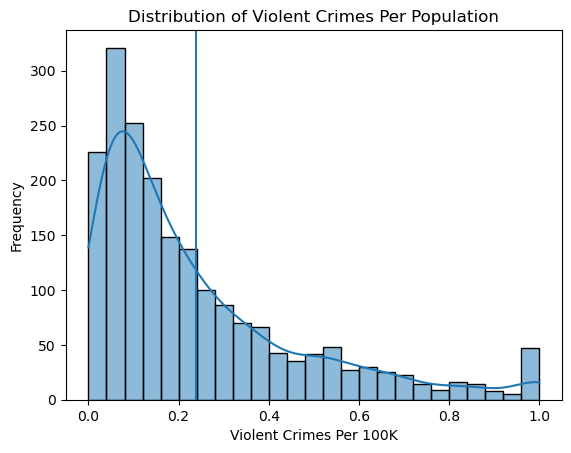

In [ ]:


plt.figure()
sns.histplot(df["ViolentCrimesPerPop"], kde=True)
plt.axvline(df["ViolentCrimesPerPop"].mean())
plt.title("Distribution of Violent Crimes Per Population")
plt.xlabel("Violent Crimes Per 100K")
plt.ylabel("Frequency")
plt.show()

In [25]:
df["log_crime"] = np.log1p(df["ViolentCrimesPerPop"])

plt.figure()
sns.histplot(df["log_crime"], kde=True)
plt.title("Log-Transformed Violent Crime Distribution")
plt.show()

NameError: name 'plt' is not defined

In [27]:
selected_vars = [
    "racepctblack",
    "racePctWhite",
    "racePctAsian",
    "racePctHisp",
    "agePct12t21",
    "agePct12t29",
    "agePct16t24",
    "agePct65up",
    "PctUsePubTrans",
    "ViolentCrimesPerPop"
]


corr = df[selected_vars].corr()
corr["ViolentCrimesPerPop"].sort_values(ascending=False)

ViolentCrimesPerPop    1.000000
racepctblack           0.631264
racePctHisp            0.293050
PctUsePubTrans         0.153829
agePct12t29            0.153357
agePct16t24            0.099347
agePct65up             0.067171
agePct12t21            0.060477
racePctAsian           0.037622
racePctWhite          -0.684770
Name: ViolentCrimesPerPop, dtype: float64

In [39]:
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

NameError: name 'plt' is not defined

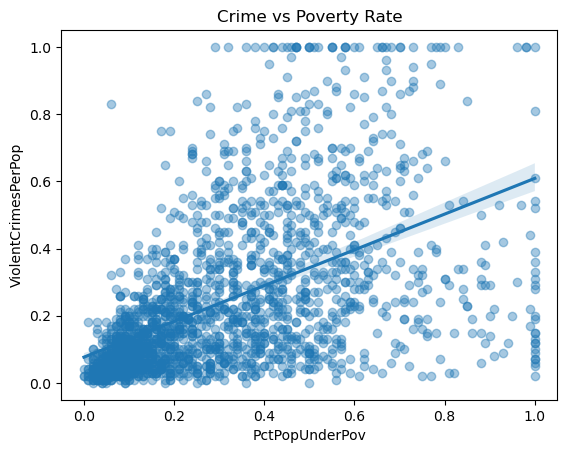

In [77]:
plt.figure()
sns.regplot(x="PctPopUnderPov",
            y="ViolentCrimesPerPop",
            data=df,
            scatter_kws={'alpha':0.4})
plt.title("Crime vs Poverty Rate")
plt.show()

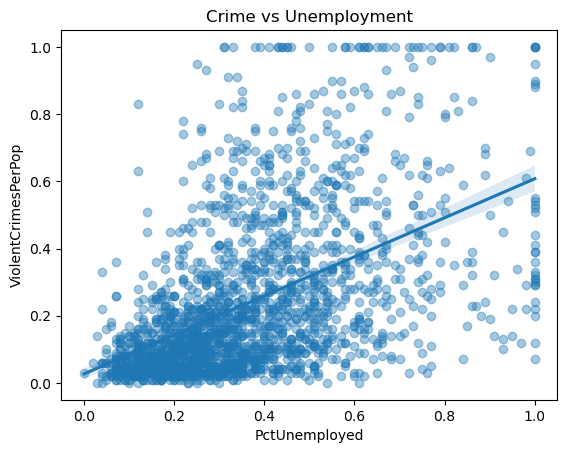

In [79]:
plt.figure()
sns.regplot(x="PctUnemployed",
            y="ViolentCrimesPerPop",
            data=df,
            scatter_kws={'alpha':0.4})
plt.title("Crime vs Unemployment")
plt.show()

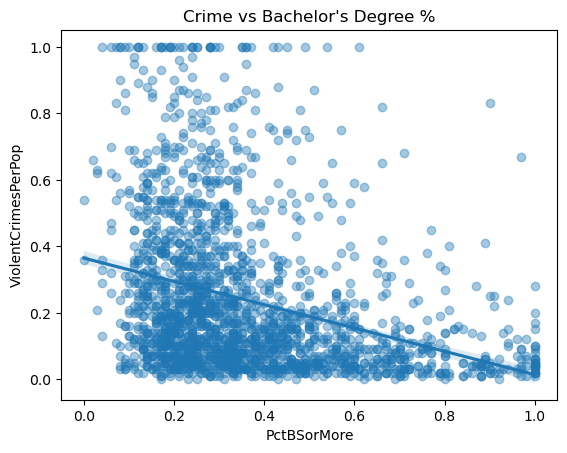

In [81]:
plt.figure()
sns.regplot(x="PctBSorMore",
            y="ViolentCrimesPerPop",
            data=df,
            scatter_kws={'alpha':0.4})
plt.title("Crime vs Bachelor's Degree %")
plt.show()

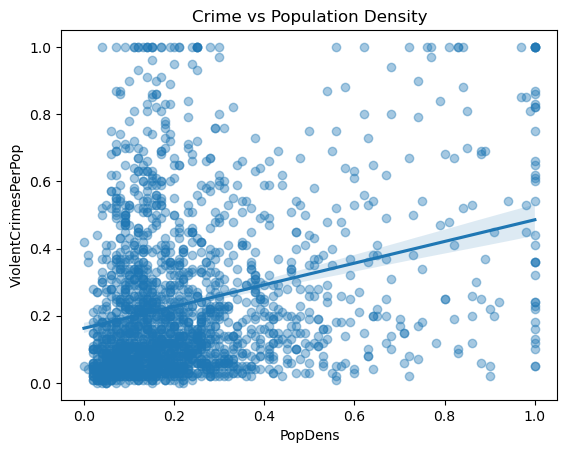

In [83]:
plt.figure()
sns.regplot(x="PopDens",
            y="ViolentCrimesPerPop",
            data=df,
            scatter_kws={'alpha':0.4})
plt.title("Crime vs Population Density")
plt.show()

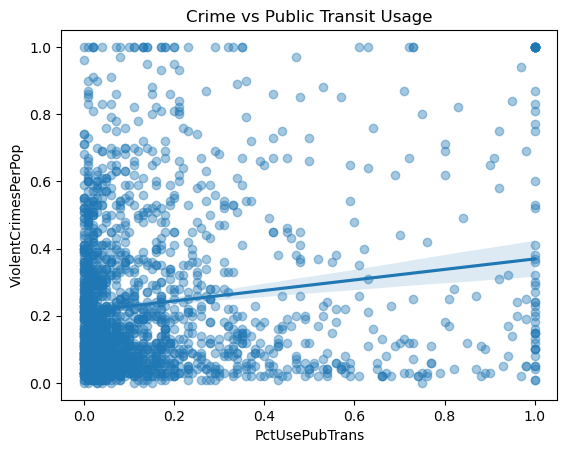

In [85]:
plt.figure()
sns.regplot(x="PctUsePubTrans",
            y="ViolentCrimesPerPop",
            data=df,
            scatter_kws={'alpha':0.4})
plt.title("Crime vs Public Transit Usage")
plt.show()

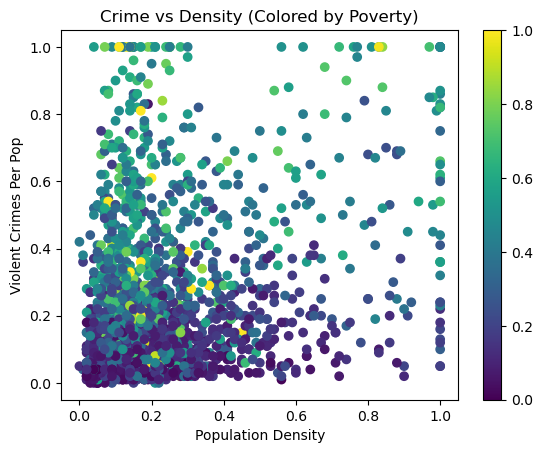

In [87]:
plt.figure()
scatter = plt.scatter(df["PopDens"],
                      df["ViolentCrimesPerPop"],
                      c=df["PctPopUnderPov"])

plt.colorbar(scatter)
plt.xlabel("Population Density")
plt.ylabel("Violent Crimes Per Pop")
plt.title("Crime vs Density (Colored by Poverty)")
plt.show()

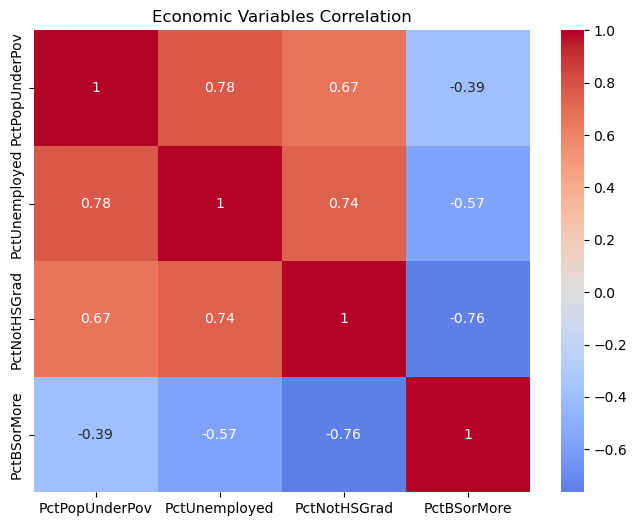

In [91]:
economic_vars = [
    "PctPopUnderPov",
    "PctUnemployed",
    "PctNotHSGrad",
    "PctBSorMore"
]


plt.figure(figsize=(8,6))
sns.heatmap(df[economic_vars].corr(),
            annot=True,
            cmap="coolwarm",
            center=0)
plt.title("Economic Variables Correlation")
plt.show()

In [7]:
urban_df = df[df["pctUrban"] > 0.75]

print("Original dataset size:", df.shape)
print("Urban dataset size:", urban_df.shape)

# Compare crime rates
df["UrbanCommunity"] = (df["pctUrban"] > 0.75).astype(int)

crime_compare = df.groupby("UrbanCommunity")["ViolentCrimesPerPop"].mean()

print("\nAverage Crime Rates:")
print(crime_compare)

Original dataset size: (1995, 124)
Urban dataset size: (1371, 124)

Average Crime Rates:
UrbanCommunity
0    0.206565
1    0.252254
Name: ViolentCrimesPerPop, dtype: float64
